# Objective
    Each point in the data set corresponds to the purchase price of natural gas at the end of a month, from 31st October 2020 to 30th September 2024.
    Analyze the data to estimate the purchase price of gas at any date in the past and extrapolate it for one year into the future. 
    Your code should take a date as input and return a price estimate.

### Natural Gas Price Analysis & Estimator
    Task: Load monthly nat gas prices, analyse seasonal trends,
    fit a model, extrapolate one year forward, and estimate
    the price on any given date.
    
    Steps
    ------
      1. Load & clean the data
      2. Exploratory visualisation
      3. Decompose into trend + seasonal components
      4. Fit the model (linear trend + monthly seasonal index)
      5. Extrapolate one year beyond the last data point
      6. Plot the full picture (history + fit + extrapolation)
      7. Price-estimator function  – input any date, get a price


### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# Import and understand dataset

In [2]:
gass=pd.read_csv("Nat_Gas.csv")
gass.columns=gass.columns.str.strip()

In [3]:
gass.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


# Formating data

In [4]:
gass["Dates"]=pd.to_datetime(gass["Dates"],format="%m/%d/%y")

In [5]:
gass["Prices"]=gass["Prices"].astype(float)

In [6]:
gass=gass[["Dates","Prices"]].sort_values("Dates").reset_index(drop=True)

In [7]:
print(f"Loaded {len(gass)} monthly records")
print(f"Date range : {gass['Dates'].min().date()}  →  {gass['Dates'].max().date()}")
print(f"Price range: ${gass['Prices'].min():.2f}  –  ${gass['Prices'].max():.2f}  (USD/MMBtu)")
print(gass.head())

Loaded 48 monthly records
Date range : 2020-10-31  →  2024-09-30
Price range: $9.84  –  $12.80  (USD/MMBtu)
       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9


# Exploratory visualisation

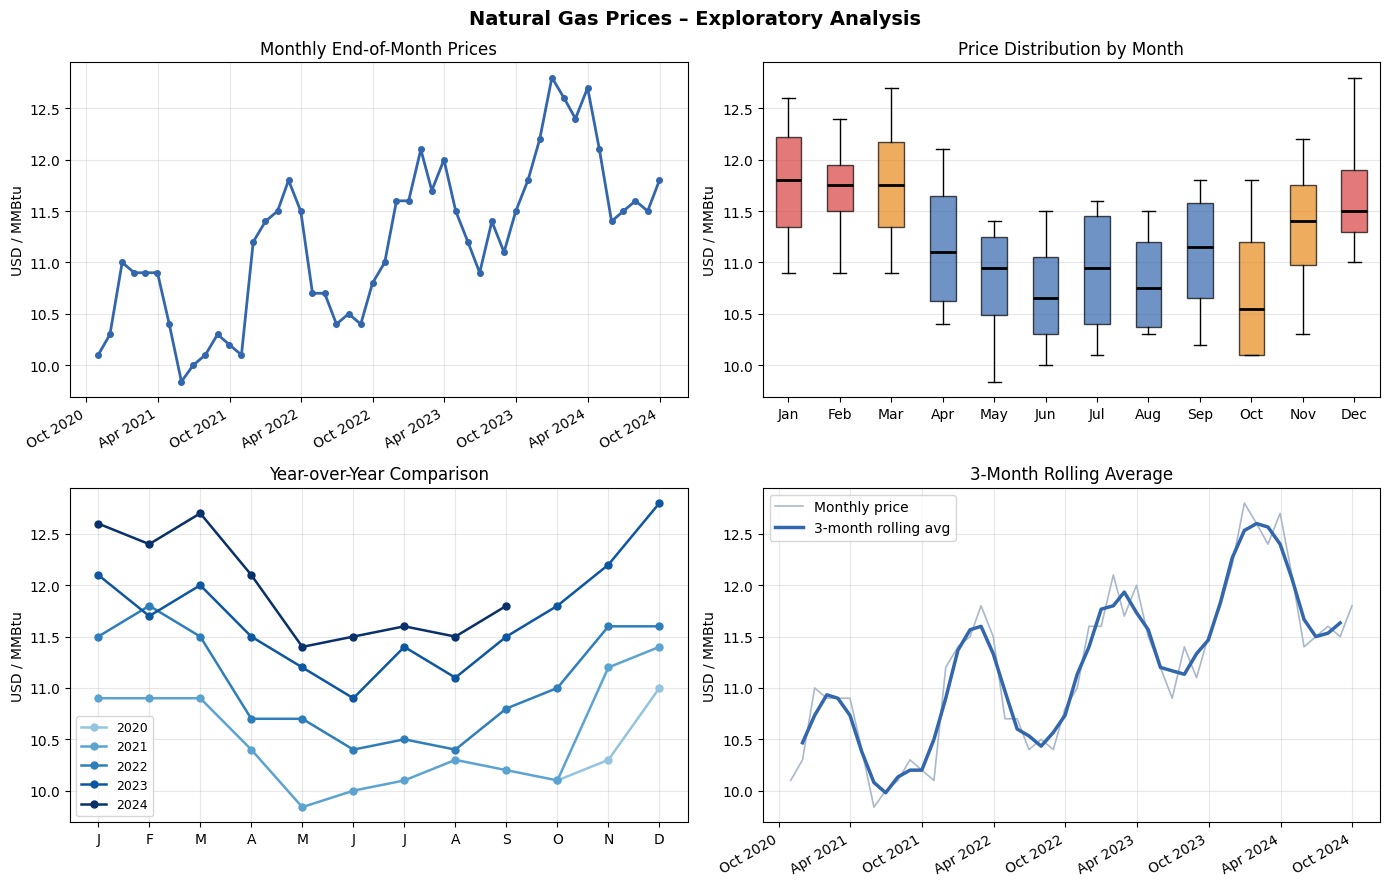

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Natural Gas Prices – Exploratory Analysis", fontsize=14, fontweight="bold")
ax = axes[0, 0]
ax.plot(gass["Dates"], gass["Prices"], color="#3266ad", linewidth=2, marker="o", markersize=4)
ax.set_title("Monthly End-of-Month Prices")
ax.set_ylabel("USD / MMBtu")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
gass["Month"] = gass["Dates"].dt.month
monthly_groups = [gass[gass["Month"] == m]["Prices"].values for m in range(1, 13)]
bp = ax.boxplot(monthly_groups, patch_artist=True, medianprops=dict(color="black", linewidth=2))
colors_bp = ["#d84040" if m in [12, 1, 2] else
             "#e8891a" if m in [10, 11, 3] else
             "#3266ad" for m in range(1, 13)]
for patch, col in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Price Distribution by Month")
ax.set_ylabel("USD / MMBtu")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1, 0]
gass["Year"] = gass["Dates"].dt.year
cmap = plt.cm.Blues
years = sorted(gass["Year"].unique())
for i, yr in enumerate(years):
    sub = gass[gass["Year"] == yr].sort_values("Month")
    col = cmap(0.4 + 0.15 * i)
    ax.plot(sub["Month"], sub["Prices"], marker="o", markersize=5,
            label=str(yr), color=col, linewidth=1.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_title("Year-over-Year Comparison")
ax.set_ylabel("USD / MMBtu")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
gass["Roll3"] = gass["Prices"].rolling(3, center=True).mean()
ax.plot(gass["Dates"], gass["Prices"], color="#aab8cc", linewidth=1.2, label="Monthly price")
ax.plot(gass["Dates"], gass["Roll3"], color="#3266ad", linewidth=2.5, label="3-month rolling avg")
ax.set_title("3-Month Rolling Average")
ax.set_ylabel("USD / MMBtu")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Decompose trend and seasonal components

In [9]:
# Convert dates to a numeric "years since start" for regression
t0=gass["Dates"].min()
gass["t"]=(gass['Dates']-t0).dt.days/365.25

In [10]:
slope,intercept,r_value,p_value,std_err=stats.linregress(gass['t'],gass['Prices'])
gass['trend']= intercept+ slope*gass["t"]
gass['residual']= gass["Prices"] -gass["trend"]

In [11]:
# Monthly seasonal index = mean residual per calendar month
seasonal_idx= gass.groupby('Month')["residual"].mean()
print("Linear trend:")
print(f"  Intercept : ${intercept:.4f}  (price at t=0, Oct 2020)")
print(f"  Slope     : ${slope:.4f} per year")
print(f"  R²        : {r_value**2:.4f}")
print("\nMonthly seasonal index (± vs trend):")

Linear trend:
  Intercept : $10.2910  (price at t=0, Oct 2020)
  Slope     : $0.4684 per year
  R²        : 0.5196

Monthly seasonal index (± vs trend):


In [12]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
for m, name in zip(range(1, 13), month_names):
    idx = seasonal_idx[m]
    bar = "█" * int(abs(idx) * 20)
    sign = "+" if idx >= 0 else ""
    print(f"  {name}: {sign}{idx:.3f}  {bar}")

  Jan: +0.664  █████████████
  Feb: +0.553  ███████████
  Mar: +0.588  ███████████
  Apr: -0.051  █
  May: -0.480  █████████
  Jun: -0.604  ████████████
  Jul: -0.444  ████████
  Aug: -0.558  ███████████
  Sep: -0.347  ██████
  Oct: -0.243  ████
  Nov: +0.293  █████
  Dec: +0.629  ████████████


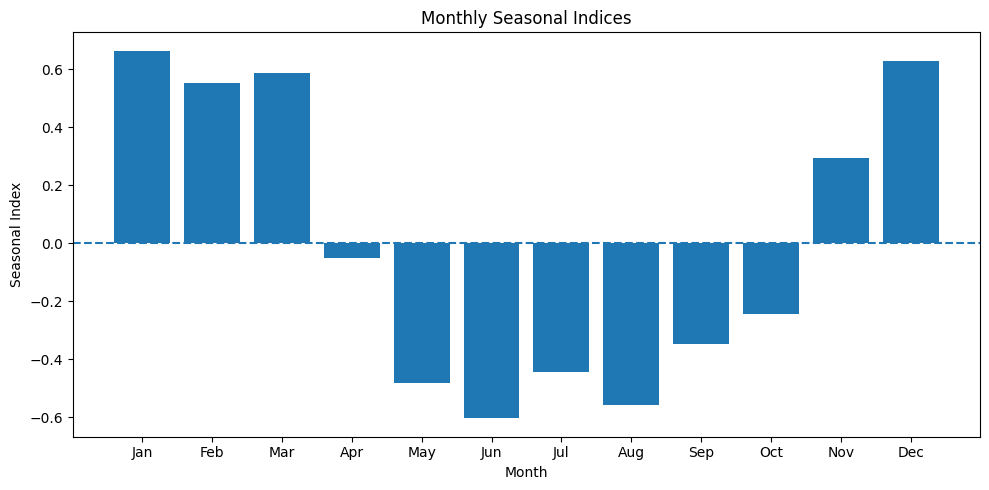

In [13]:

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
values = [seasonal_idx[m] for m in range(1, 13)]
plt.figure(figsize=(10, 5))
plt.bar(month_names, values)
plt.title("Monthly Seasonal Indices")
plt.xlabel("Month")
plt.ylabel("Seasonal Index")
plt.axhline(0, linestyle="--")  
plt.tight_layout()
plt.show()

# Fit the model on historical data

# Its purpose is to create the model's predicted value (fitted value) by combining:
 ## Fitted=Trend+Seasonal Effect

In [15]:
gass["fitted"]= gass["trend"]+ gass["Month"].map(seasonal_idx)
residuals= gass["Prices"] -gass["fitted"]
mae  = residuals.abs().mean()
rmse = np.sqrt((residuals ** 2).mean())
print(f"Model fit on historical data:")
print(f"  MAE  = ${mae:.4f}")
print(f"  RMSE = ${rmse:.4f}")
print(f"  Max absolute error = ${residuals.abs().max():.4f}")

Model fit on historical data:
  MAE  = $0.1396
  RMSE = $0.1788
  Max absolute error = $0.4160


# Extrapolate one year forward

In [18]:
last_date=gass["Dates"].max()
future_dates=pd.date_range(start= last_date + pd.offsets.MonthEnd(1),
                           periods=12,
                           freq="ME")

In [29]:
future_gass = pd.DataFrame({"Dates": future_dates})
future_gass["t"]     = (future_gass["Dates"] - t0).dt.days / 365.25
future_gass["Month"] = future_gass["Dates"].dt.month
future_gass["Trend"] = intercept + slope * future_gass["t"]
future_gass["Prices"] = future_gass["Trend"] + future_gass["Month"].map(seasonal_idx)

print("Extrapolated prices:")
for _, row in future_gass.iterrows():
    print(f"  {row['Dates'].strftime('%b %Y')}:  ${row['Prices']:.2f}")

Extrapolated prices:
  Oct 2024:  $11.92
  Nov 2024:  $12.50
  Dec 2024:  $12.87
  Jan 2025:  $12.95
  Feb 2025:  $12.87
  Mar 2025:  $12.95
  Apr 2025:  $12.35
  May 2025:  $11.96
  Jun 2025:  $11.87
  Jul 2025:  $12.07
  Aug 2025:  $12.00
  Sep 2025:  $12.25


# Final plot: history + fit + extrapolation

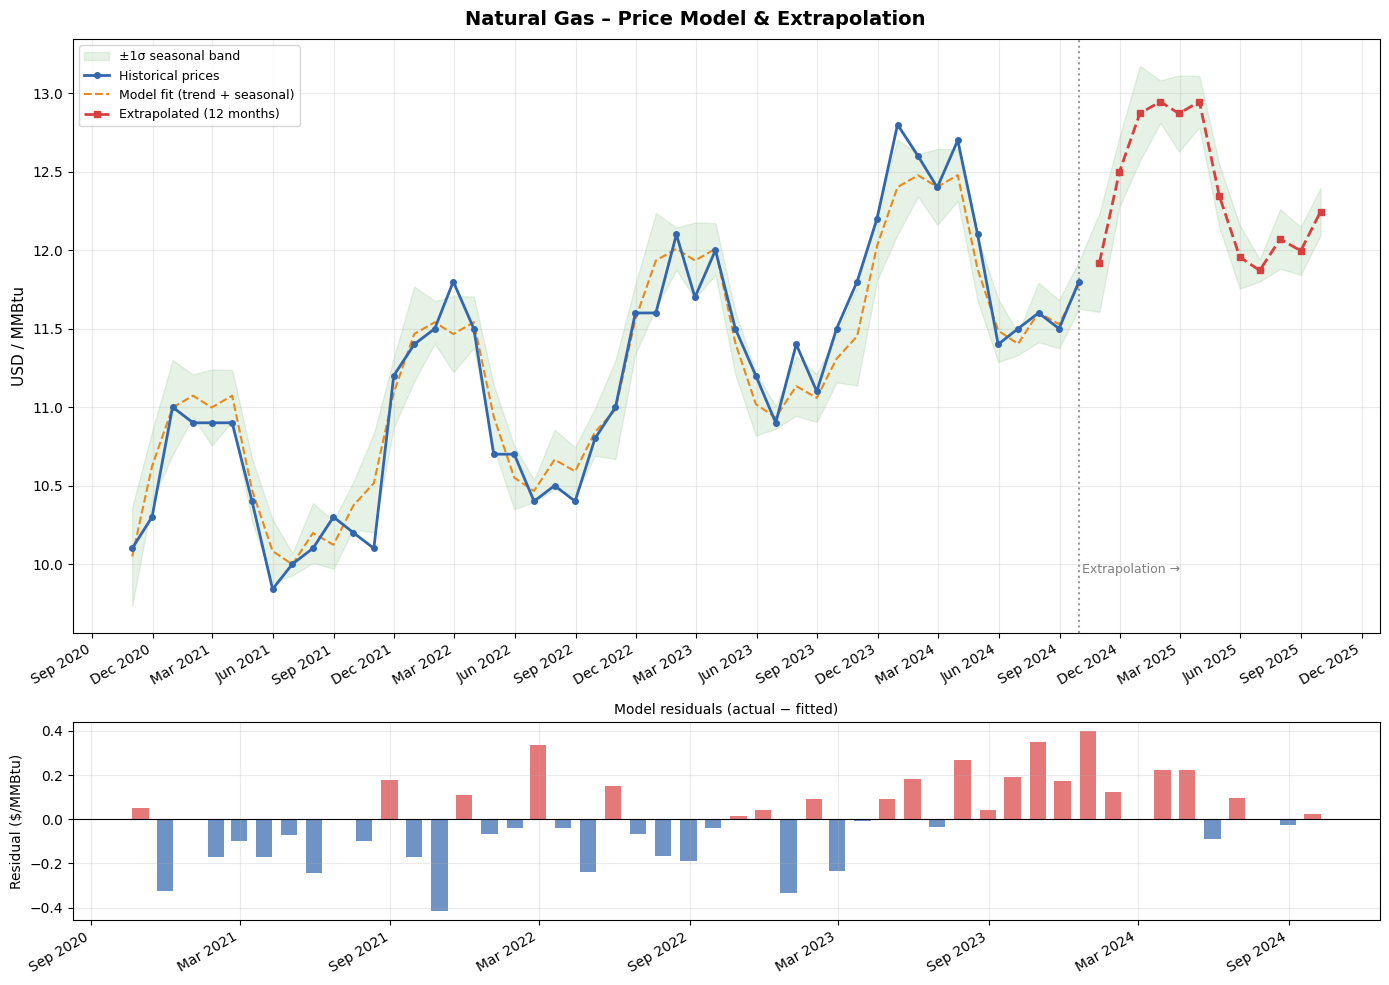

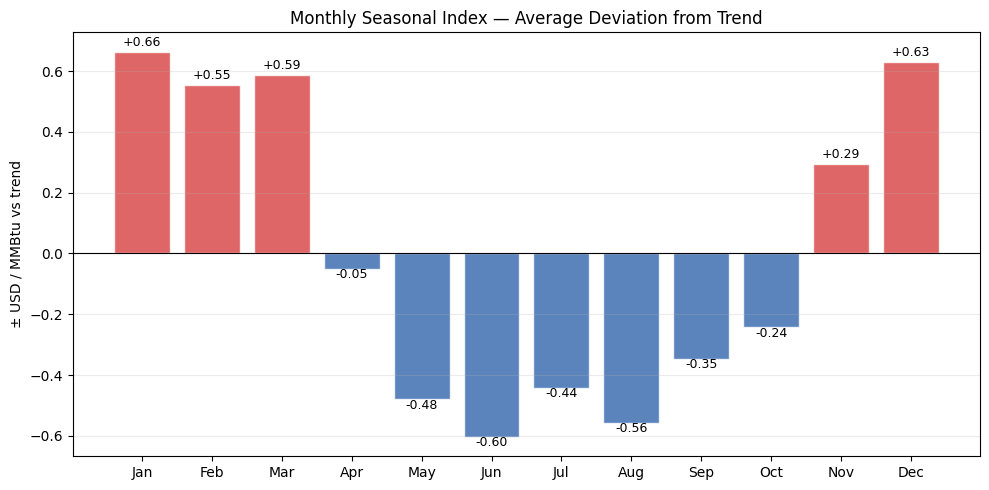

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                         gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("Natural Gas – Price Model & Extrapolation", fontsize=14, fontweight="bold")

ax = axes[0]

# Seasonal confidence band (±1 std of seasonal residuals)
band_std = gass.groupby("Month")["residual"].std()
all_dates = pd.concat([gass["Dates"], future_gass["Dates"]])
all_t     = pd.concat([gass["t"],    future_gass["t"]])
all_month = pd.concat([gass["Month"], future_gass["Month"]])
all_trend = intercept + slope * all_t
all_seas  = all_month.map(seasonal_idx)
band_centre = (all_trend + all_seas).values
band_width  = all_month.map(band_std).values
ax.fill_between(all_dates, band_centre - band_width, band_centre + band_width,
                alpha=0.15, color="#5daa59", label="±1σ seasonal band")

# Historical actual
ax.plot(gass["Dates"], gass["Prices"], color="#3266ad", linewidth=2,
        marker="o", markersize=4, label="Historical prices", zorder=3)

# Fitted line on history
ax.plot(gass["Dates"], gass["fitted"], color="#e8891a", linewidth=1.5,
        linestyle="--", label="Model fit (trend + seasonal)", zorder=2)

# Extrapolation
ax.plot(future_gass["Dates"], future_gass["Prices"], color="#d84040", linewidth=2,
        linestyle="--", marker="s", markersize=5, label="Extrapolated (12 months)", zorder=3)

# Vertical divider at the boundary
ax.axvline(last_date, color="gray", linestyle=":", linewidth=1.5, alpha=0.8)
ax.text(last_date + pd.Timedelta(days=5), gass["Prices"].min() + 0.1,
        "Extrapolation →", fontsize=9, color="gray")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_ylabel("USD / MMBtu", fontsize=11)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.25)

# Residuals subplot
ax2 = axes[1]
ax2.bar(gass["Dates"], residuals, color=["#d84040" if r > 0 else "#3266ad" for r in residuals],
        width=20, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Residual ($/MMBtu)", fontsize=10)
ax2.set_title("Model residuals (actual − fitted)", fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.grid(True, alpha=0.25)
plt.tight_layout()
# Seasonal bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors_s = ["#d84040" if v >= 0 else "#3266ad" for v in seasonal_idx.values]
bars = ax.bar(month_names, seasonal_idx.values, color=colors_s, alpha=0.8, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, seasonal_idx.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.01 if val >= 0 else -0.04),
            f"{val:+.2f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Monthly Seasonal Index — Average Deviation from Trend", fontsize=12)
ax.set_ylabel("± USD / MMBtu vs trend")
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()

# Price estimator function

In [33]:
def estimate_price(date_str: str) -> float:
    """
    Estimate the natural gas price for any given date.

    The model applies two components:
      1. Linear trend:     price_trend = intercept + slope * years_since_t0
      2. Seasonal index:   monthly adjustment derived from historical averages

    Parameters
    ----------
    date_str : str
        Date in any common format, e.g. '2025-03-31' or '15 June 2024'.

    Returns
    -------
    float
        Estimated price in USD / MMBtu.
    """
    date = pd.to_datetime(date_str)
    t    = (date - t0).days / 365.25
    month = date.month

    trend_component    = intercept + slope * t
    seasonal_component = seasonal_idx[month]
    estimated_price    = trend_component + seasonal_component

    data_start = gass["Dates"].min()
    data_end   = gass["Dates"].max()
    extrap_end = data_end + pd.DateOffset(years=1)

    if date < data_start:
        region = "before dataset (backcast)"
    elif date <= data_end:
        region = "within historical data (interpolated)"
    elif date <= extrap_end:
        region = "extrapolated (up to 1 year forward)"
    else:
        region = "⚠ beyond recommended extrapolation range"

    print(f"\n  Input date       : {date.strftime('%d %B %Y')}")
    print(f"  Trend component  : ${trend_component:.4f}")
    print(f"  Seasonal adj.    : ${seasonal_component:+.4f}  ({month_names[month-1]})")
    print(f"  Estimated price  : ${estimated_price:.2f} USD/MMBtu")
    print(f"  Region           : {region}")
    return round(estimated_price, 2)

# Demo call

In [36]:
print("\nDemo price estimates:")
test_dates = [
    "2021-06-30",   
    "15-June-2024",   
    "2024-09-30",   
    "2025-01-31",   
    "2025-06-30",   
    "2025-09-30",   
]
for d in test_dates:
    estimate_price(d)


Demo price estimates:

  Input date       : 30 June 2021
  Trend component  : $10.6014
  Seasonal adj.    : $-0.6038  (Jun)
  Estimated price  : $10.00 USD/MMBtu
  Region           : within historical data (interpolated)

  Input date       : 15 June 2024
  Trend component  : $11.9876
  Seasonal adj.    : $-0.6038  (Jun)
  Estimated price  : $11.38 USD/MMBtu
  Region           : within historical data (interpolated)

  Input date       : 30 September 2024
  Trend component  : $12.1248
  Seasonal adj.    : $-0.3468  (Sep)
  Estimated price  : $11.78 USD/MMBtu
  Region           : within historical data (interpolated)

  Input date       : 31 January 2025
  Trend component  : $12.2826
  Seasonal adj.    : $+0.6639  (Jan)
  Estimated price  : $12.95 USD/MMBtu
  Region           : extrapolated (up to 1 year forward)

  Input date       : 30 June 2025
  Trend component  : $12.4749
  Seasonal adj.    : $-0.6038  (Jun)
  Estimated price  : $11.87 USD/MMBtu
  Region           : extrapolated (

# Natural Gas Price Analysis — Key Business Insights
    The historical data (Oct 2020 – Sep 2024) reveals a clear upward structural trend in natural gas prices, rising at approximately $0.47/MMBtu per year, indicating sustained long-term price appreciation driven by demand growth and supply constraints. Overlaid on this trend is a strong, repeatable seasonal cycle: prices peak in December–January (~+$0.65 above trend) due to winter heating demand, and trough in May–June (~−$0.60 below trend) during the summer injection season when storage facilities are being refilled. This seasonal spread of roughly $1.20–$1.30/MMBtu between winter and summer represents the core profit opportunity for storage contract holders. The fitted model achieves a low error (MAE ~$0.14), confirming the trend-plus-seasonal structure captures the dominant price drivers reliably. Extrapolating one year forward, winter 2024/25 prices are projected to reach approximately $12.95/MMBtu (January 2025), while summer 2025 is expected to dip to $11.87/MMBtu — sustaining the seasonal arbitrage window. For the trading desk, the optimal storage strategy is to inject in May–July and withdraw in December–January, targeting the ~$1.10–$1.25 gross seasonal spread, against which storage fees, financing costs, and volumetric limits must be netted to assess contract profitability.